# 06 · Analysis & charts

The questions from the brief, answered with charts. Every number comes from `02_Database/geo_inr_analytics.db`.

> **Series:** 01 Ingest → 02 Align & transform → 03 Event windows → 04 Database → 05 Results report → 06 Analysis & charts. Run them in order (or run `python run_pipeline.py` from the project folder). Paths and settings live in `config.py`.

> **How to read everything below:** these are **temporal associations**, meaning what moved *around* an event date.
> They are not causal effects. The confounders (monetary policy, oil, global risk, US-dollar strength, domestic
> conditions, capital flows, RBI intervention) are shown next to the results on purpose.

Figures are also saved to `05_Documentation/Figures/`.

In [1]:
import sqlite3
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm
from config import DB_PATH, DOCS

# ---- chart style (one system for every figure) -----------------------------------------
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"        # categorical slots 1-3
INK, INK2, MUTED, GRID = "#0b0b0b", "#52514e", "#8a8984", "#e6e5e1"
DIVERGING = LinearSegmentedColormap.from_list("div", ["#2a78d6", "#f0efec", "#e34948"])   # blue <-> grey <-> red
plt.rcParams.update({"axes.axisbelow": True, 
    "figure.dpi": 110, "savefig.dpi": 150, "font.size": 9.5, "axes.titlesize": 11.5, "axes.titleweight": "bold",
    "axes.titlelocation": "left", "axes.edgecolor": MUTED, "axes.labelcolor": INK2, "text.color": INK,
    "xtick.color": INK2, "ytick.color": INK2, "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False, "lines.linewidth": 1.6, "legend.frameon": False,
})
FIG_DIR = DOCS / "Figures"
FIG_DIR.mkdir(exist_ok=True)

def save(fig, name):
    fig.savefig(FIG_DIR / f"{name}.png", bbox_inches="tight", facecolor="white")

con = sqlite3.connect(DB_PATH)
q = lambda sql: pd.read_sql(sql, con)
events = q("SELECT event_id, event_name, short_name, event_label, india_direct FROM dim_event ORDER BY event_id")
anchors = q("SELECT event_id, t0_date FROM fact_event_anchor WHERE basis = 'RBI' AND covered = 1")
anchors["t0_date"] = pd.to_datetime(anchors["t0_date"])
daily = q("""SELECT d.date, f.* FROM fact_daily_aligned f JOIN dim_date d USING (date_key)
             WHERE f.basis = 'RBI' ORDER BY d.date""")
daily["date"] = pd.to_datetime(daily["date"])
ew = q("SELECT * FROM fact_event_window WHERE basis = 'RBI'")
ctx = q("SELECT * FROM fact_event_window_context WHERE basis = 'RBI'")
WINDOW_ORDER = ["PRE_30", "PRE_14", "PRE_7", "EVENT", "POST_7", "POST_14", "POST_30", "POST_90"]
print(f"{len(daily):,} trading days | {len(events)} events | {len(ew):,} event-window rows")

3,315 trading days | 13 events | 936 event-window rows


## 1 · The rupee from 2013 to 2026, with the 13 events

USD/INR (RBI reference rate). **Up = rupee weaker.** Each dot marks t(0), the first trading day after the news.

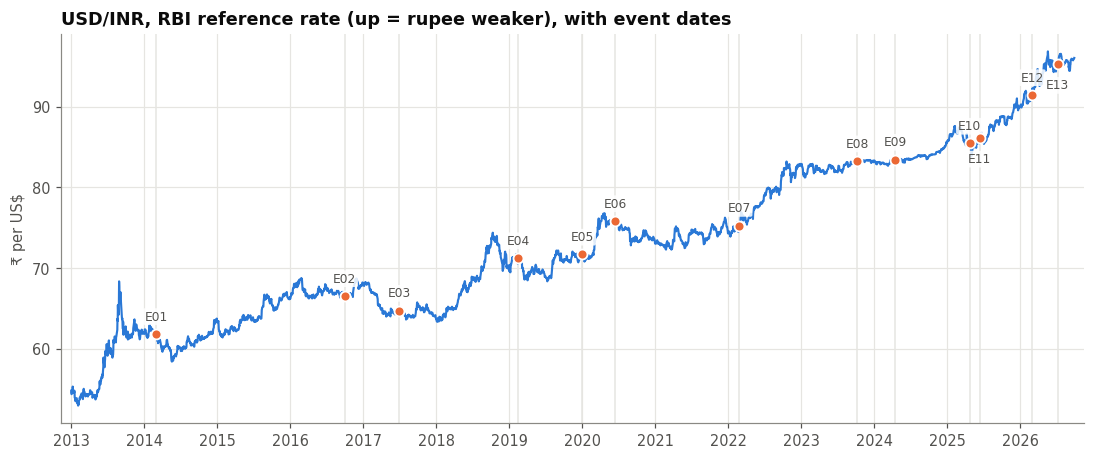

In [2]:
fig, ax = plt.subplots(figsize=(12, 4.6))
ax.plot(daily.date, daily.usdinr, color=BLUE, lw=1.4)
pts = anchors.merge(daily[["date", "usdinr"]], left_on="t0_date", right_on="date").sort_values("date")
prev = None
for _, r in pts.iterrows():
    below = prev is not None and (r.date - prev).days < 150      # stagger labels of events close in time
    ax.axvline(r.date, color=GRID, lw=1, zorder=0)
    ax.plot(r.date, r.usdinr, "o", ms=6.5, color=ORANGE, mec="white", mew=1.2, zorder=3)
    ax.annotate(r.event_id, (r.date, r.usdinr), xytext=(0, -16 if below else 9), textcoords="offset points",
                ha="center", fontsize=8, color=INK2,
                bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.85))
    prev = None if below else r.date
ax.set_title("USD/INR, RBI reference rate (up = rupee weaker), with event dates")
ax.set_ylabel("₹ per US$")
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.margins(x=0.01)
save(fig, "01_usdinr_with_events"); plt.show()

In [3]:
events.merge(anchors, on="event_id")[["event_id", "event_name", "t0_date", "india_direct"]]

,event_id,event_name,t0_date,india_direct
0,E01,Russia authorises force in Ukraine / Crimea an...,2014-03-03,N
1,E02,Indian Army cross-LoC 'surgical strikes' (post...,2016-09-29,Y
2,E03,Doklam India-China standoff,2017-06-30,Y
3,E04,Pulwama attack and Balakot airstrike,2019-02-15,Y
4,E05,US strike kills IRGC commander Qassem Soleimani,2020-01-03,N
5,E06,Galwan Valley clash,2020-06-16,Y
6,E07,Russia's full-scale invasion of Ukraine,2022-02-24,N
7,E08,Hamas attack on Israel and Israel-Gaza war,2023-10-09,N
8,E09,Iran's first direct missile and drone attack o...,2024-04-15,N
9,E10,Pahalgam attack and Operation Sindoor,2025-04-23,Y


## 2 · Every event, every window: one heatmap

USD/INR % change in each window. **Red = rupee weaker, blue = rupee stronger**, and grey means close to no change.
Italic `*` marks a partial window (the data ends before t+k).

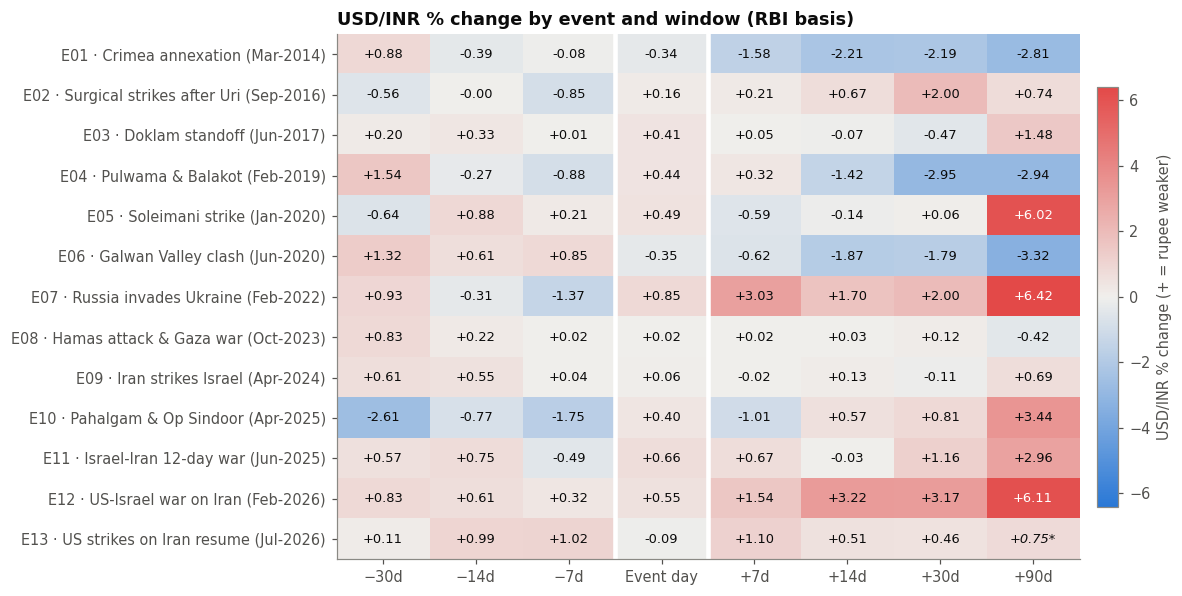

In [4]:
m = ew[ew.series_id == "USDINR"].pivot(index="event_id", columns="window_id", values="change")[WINDOW_ORDER]
st = ew[ew.series_id == "USDINR"].pivot(index="event_id", columns="window_id", values="status")[WINDOW_ORDER]
lim = np.nanmax(np.abs(m.values))
fig, ax = plt.subplots(figsize=(10.5, 6.2))
im = ax.imshow(m.values, cmap=DIVERGING, norm=TwoSlopeNorm(0, -lim, lim), aspect="auto")
for i in range(m.shape[0]):
    for j in range(m.shape[1]):
        v = m.values[i, j]
        if np.isnan(v):
            continue
        partial = st.values[i, j] == "partial"
        ax.text(j, i, f"{v:+.2f}{'*' if partial else ''}", ha="center", va="center", fontsize=8.5,
                color=INK if abs(v) < lim * 0.6 else "white", style="italic" if partial else "normal")
labels = events.set_index("event_id").loc[m.index, "event_label"]
ax.set_yticks(range(len(m.index)), labels)
ax.set_xticks(range(len(WINDOW_ORDER)), ["−30d", "−14d", "−7d", "Event day", "+7d", "+14d", "+30d", "+90d"])
ax.grid(False)
ax.axvline(2.5, color="white", lw=3); ax.axvline(3.5, color="white", lw=3)
cb = fig.colorbar(im, ax=ax, shrink=0.8, pad=0.02); cb.set_label("USD/INR % change (+ = rupee weaker)")
ax.set_title("USD/INR % change by event and window (RBI basis)")
save(fig, "02_event_window_heatmap"); plt.show()

In [5]:
summary = m.agg(["median", "mean", "min", "max"]).T.round(2)
summary["events_rupee_weaker"] = (m > 0).sum().values
summary["events_measured"] = m.notna().sum().values
summary

,median,mean,min,max,events_rupee_weaker,events_measured
window_id,,,,,,
PRE_30,0.61,0.31,-2.61,1.54,10,13
PRE_14,0.33,0.25,-0.77,0.99,8,13
PRE_7,0.01,-0.23,-1.75,1.02,7,13
EVENT,0.40,0.25,-0.35,0.85,10,13
POST_7,0.05,0.24,-1.58,3.03,8,13
POST_14,0.03,0.08,-2.21,3.22,7,13
POST_30,0.12,0.17,-2.95,3.17,8,13
POST_90,0.75,1.47,-3.32,6.42,9,13


**What the table says (descriptively):** on the **event day** itself, USD/INR moves are small, typically well under 1%.
Over **+90 days** the spread is wide, from about −3% to +6%. That width is where the confounders dominate: COVID
inside E05's window, the 2022 Fed hiking cycle inside E07's, and the 2026 oil shock inside E12's.

## 3 · The path around each event

Each panel shows USD/INR indexed to **100 at t(−1)** from 30 trading days before to 90 after. The vertical line is t(0).
All panels share the same scale, so they can be compared directly.

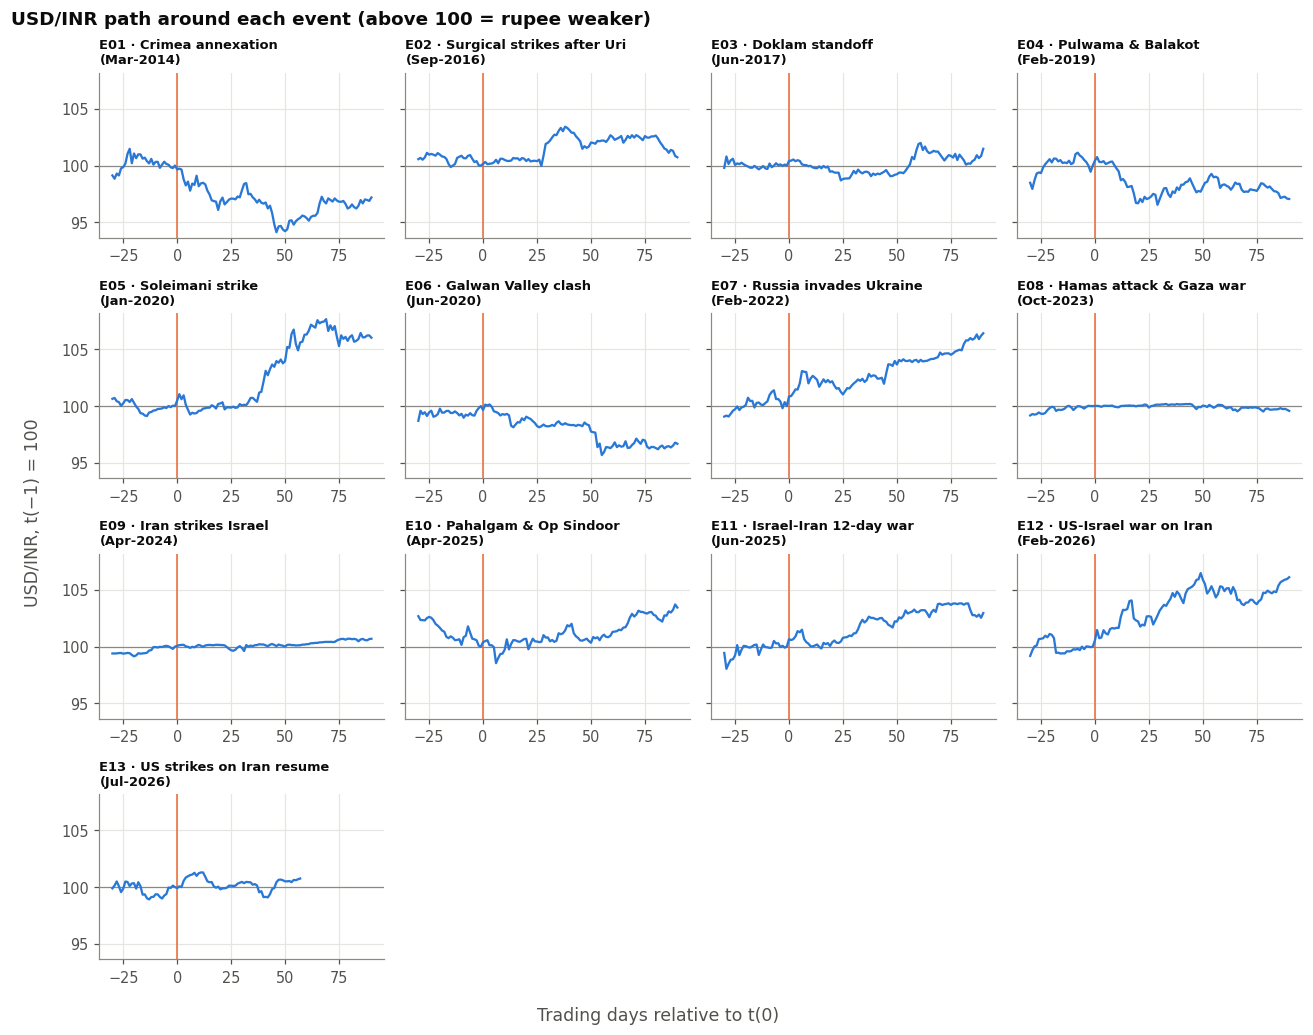

In [6]:
path = q("""SELECT event_id, rel_day, indexed_value FROM fact_event_path
             WHERE basis = 'RBI' AND series_id = 'USDINR'""")
ev_ids = list(events.event_id)
fig, axes = plt.subplots(4, 4, figsize=(12, 9.5), sharex=True, sharey=True)
ymin, ymax = path.indexed_value.min() - 0.5, path.indexed_value.max() + 0.5
for ax, eid in zip(axes.flat, ev_ids):
    p = path[path.event_id == eid]
    ax.axhline(100, color=MUTED, lw=0.8); ax.axvline(0, color=ORANGE, lw=1)
    ax.plot(p.rel_day, p.indexed_value, color=BLUE, lw=1.5)
    ax.set_title(events.set_index("event_id").loc[eid, "event_label"].replace(" (", "\n("), fontsize=8.5)
    ax.set_ylim(ymin, ymax)
    ax.tick_params(labelbottom=True)
for ax in list(axes.flat)[len(ev_ids):]:
    ax.axis("off")
fig.supxlabel("Trading days relative to t(0)", color=INK2); fig.supylabel("USD/INR, t(−1) = 100", color=INK2)
fig.suptitle("USD/INR path around each event (above 100 = rupee weaker)", x=0.01, ha="left",
             fontweight="bold", fontsize=12)
fig.tight_layout()
save(fig, "03_event_paths"); plt.show()

## 4 · Oil: did USD/INR move with Brent?

Each dot is **one event**, showing Brent's % change against USD/INR's % change over the **30 trading days after** the
event. India imports most of its crude oil, which makes oil a plausible channel. But oil also reacts to the same
events, and to unrelated supply news such as OPEC's decision in September 2016.

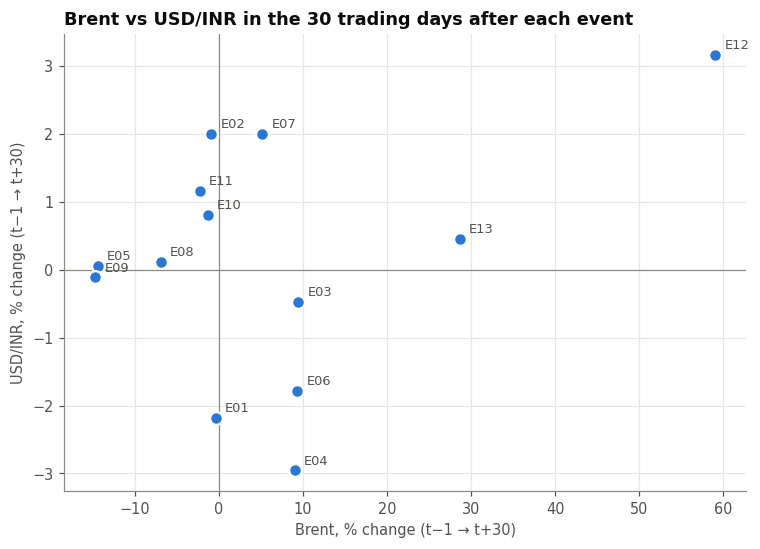

Across 13 events: correlation +0.35 - 12-13 points, so this is a description, not evidence of a relationship.


In [7]:
w = "POST_30"
pivot = ew[ew.window_id == w].pivot(index="event_id", columns="series_id", values="change")
fig, ax = plt.subplots(figsize=(8, 5.4))
ax.axhline(0, color=MUTED, lw=0.8); ax.axvline(0, color=MUTED, lw=0.8)
ax.scatter(pivot.BRENT, pivot.USDINR, s=70, color=BLUE, edgecolor="white", linewidth=1.5, zorder=3)
for eid, r in pivot.iterrows():
    ax.annotate(eid, (r.BRENT, r.USDINR), xytext=(6, 4), textcoords="offset points", fontsize=8.5, color=INK2)
ax.set_xlabel("Brent, % change (t−1 → t+30)"); ax.set_ylabel("USD/INR, % change (t−1 → t+30)")
ax.set_title("Brent vs USD/INR in the 30 trading days after each event")
save(fig, "04_brent_vs_usdinr"); plt.show()
r = pivot[["BRENT", "USDINR"]].dropna().corr().iloc[0, 1]
print(f"Across {pivot[['BRENT','USDINR']].dropna().shape[0]} events: correlation {r:+.2f} "
      "- 12-13 points, so this is a description, not evidence of a relationship.")

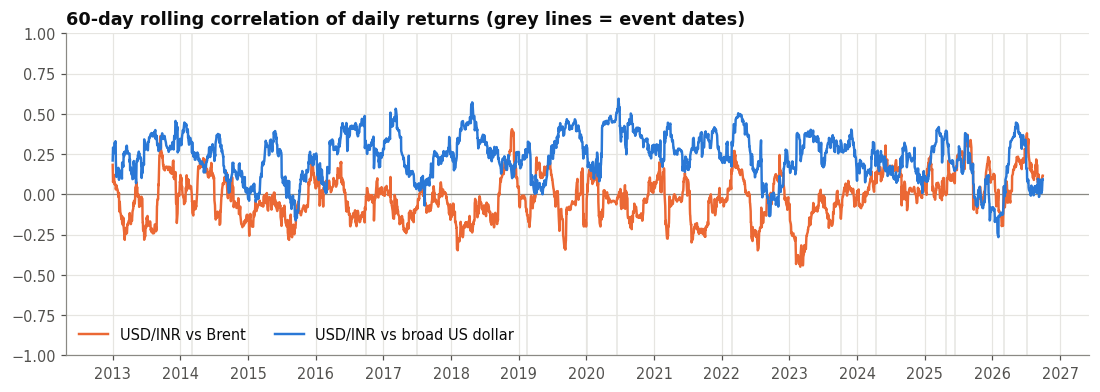

In [8]:
corr = daily.set_index("date")[["corr60_brent", "corr60_dxy"]].dropna()
fig, ax = plt.subplots(figsize=(12, 3.8))
ax.axhline(0, color=MUTED, lw=0.8)
ax.plot(corr.index, corr.corr60_brent, color=ORANGE, label="USD/INR vs Brent")
ax.plot(corr.index, corr.corr60_dxy, color=BLUE, label="USD/INR vs broad US dollar")
for d in anchors.t0_date:
    ax.axvline(d, color=GRID, lw=1, zorder=0)
ax.set_ylim(-1, 1); ax.legend(loc="lower left", ncol=2)
ax.set_title("60-day rolling correlation of daily returns (grey lines = event dates)")
ax.xaxis.set_major_locator(mdates.YearLocator()); ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
save(fig, "05_rolling_correlation"); plt.show()

Over 60-day windows, the rupee's daily-return correlation with the **broad US dollar** averages about **+0.24**, while
its correlation with **Brent** averages about **0**. The dollar link is the stronger of the two on roughly **four days
in five** (computed in the next cell). That points to the dollar-strength confounder: much of what looks like an
"event effect" on USD/INR is the dollar moving against every currency.

In [9]:
c = daily[["corr60_brent", "corr60_dxy"]].dropna()
print(f"mean 60-day correlation  vs Brent: {c.corr60_brent.mean():+.2f}   vs broad USD: {c.corr60_dxy.mean():+.2f}")
print(f"days where |corr with USD| > |corr with Brent|: {(c.corr60_dxy.abs() > c.corr60_brent.abs()).mean():.0%}")

mean 60-day correlation  vs Brent: -0.02   vs broad USD: +0.24
days where |corr with USD| > |corr with Brent|: 79%


## 5 · The rupee, or the dollar? USD/INR vs the broad US dollar index

If USD/INR rose by about the same amount as the dollar rose against 26 currencies, the move was mostly **about the
dollar**, not the rupee.

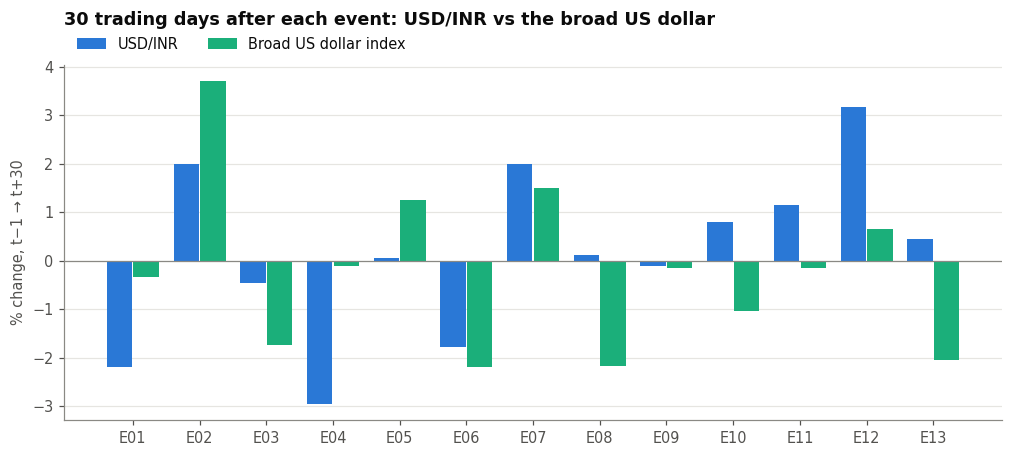

series_id,USDINR,DXY_BROAD,rupee_specific_pp
event_id,,,
E01,-2.19,-0.33,-1.86
E02,2.00,3.71,-1.71
E03,-0.47,-1.75,1.28
E04,-2.95,-0.11,-2.84
E05,0.06,1.26,-1.20
E06,-1.79,-2.20,0.41
E07,2.00,1.50,0.50
E08,0.12,-2.17,2.29
E09,-0.11,-0.16,0.04


In [10]:
p = ew[ew.window_id == "POST_30"].pivot(index="event_id", columns="series_id", values="change")[["USDINR", "DXY_BROAD"]]
x = np.arange(len(p)); wdt = 0.38
fig, ax = plt.subplots(figsize=(11, 4.2))
ax.axhline(0, color=MUTED, lw=0.8)
ax.bar(x - wdt/2 - 0.01, p.USDINR, wdt, color=BLUE, label="USD/INR")
ax.bar(x + wdt/2 + 0.01, p.DXY_BROAD, wdt, color=AQUA, label="Broad US dollar index")
ax.set_xticks(x, p.index); ax.set_ylabel("% change, t−1 → t+30")
ax.legend(ncol=2, loc="lower left", bbox_to_anchor=(0, 1.0))
ax.set_title("30 trading days after each event: USD/INR vs the broad US dollar", pad=26)
ax.grid(axis="x", visible=False)
save(fig, "06_usdinr_vs_dollar"); plt.show()
(p.assign(rupee_specific_pp=p.USDINR - p.DXY_BROAD)).round(2)

## 6 · Gold and Indian equities around events

Gold is the safe-haven channel and the Nifty 50 is the domestic risk-appetite channel. Both are shown over the 30
trading days after each event.

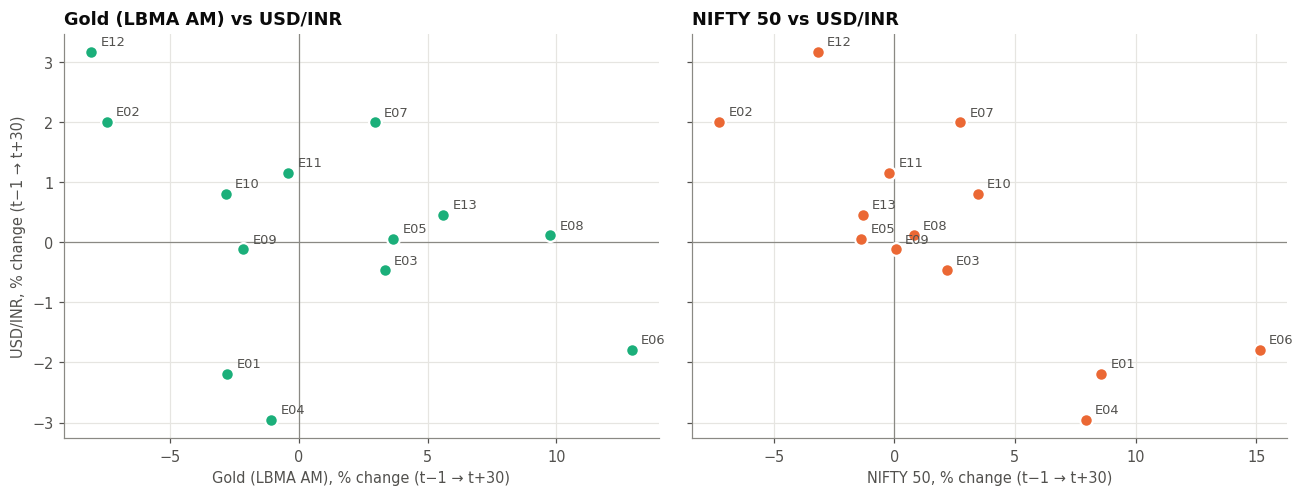

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6), sharey=True)
for ax, sid, name, col in [(axes[0], "GOLD_USD", "Gold (LBMA AM)", AQUA), (axes[1], "NIFTY50", "NIFTY 50", ORANGE)]:
    ax.axhline(0, color=MUTED, lw=0.8); ax.axvline(0, color=MUTED, lw=0.8)
    ax.scatter(pivot[sid], pivot.USDINR, s=70, color=col, edgecolor="white", linewidth=1.5, zorder=3)
    for eid, r in pivot.iterrows():
        if pd.notna(r[sid]):
            ax.annotate(eid, (r[sid], r.USDINR), xytext=(6, 4), textcoords="offset points", fontsize=8.5, color=INK2)
    ax.set_xlabel(f"{name}, % change (t−1 → t+30)")
    ax.set_title(f"{name} vs USD/INR")
axes[0].set_ylabel("USD/INR, % change (t−1 → t+30)")
fig.tight_layout(); save(fig, "07_gold_nifty_vs_usdinr"); plt.show()

## 7 · The central bank in the background: RBI's dollar sales and purchases

Monthly net purchase (+) or sale (−) of US dollars by the RBI. **Heavy selling means RBI was leaning against rupee
weakness**, so a muted USD/INR move can hide real pressure.

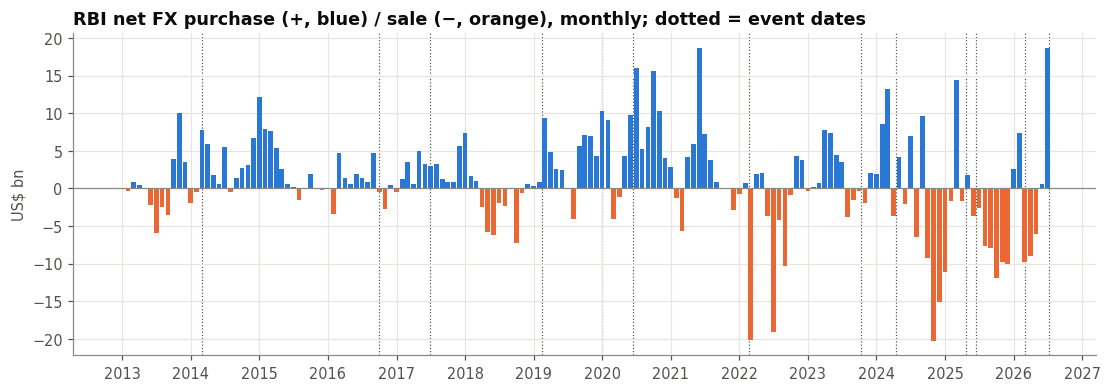

,event_id,rbi_fx_months,rbi_net_fx_usd_bn
2,E01,Feb-2014..Apr-2014,13.1
10,E02,Sep-2016..Nov-2016,1.5
18,E03,Jun-2017..Aug-2017,9.5
26,E04,Feb-2019..Apr-2019,15.1
34,E05,Jan-2020..Feb-2020,19.4
42,E06,Jun-2020..Jul-2020,25.8
50,E07,Feb-2022..Apr-2022,-17.4
58,E08,Oct-2023..Nov-2023,-2.2
66,E09,Apr-2024..May-2024,0.6
74,E10,Apr-2025..Jun-2025,-3.6


In [12]:
fx = q("""SELECT period_start, value FROM fact_macro WHERE series_id = 'IN_RBI_FX_NET' ORDER BY period_start""")
fx["period_start"] = pd.to_datetime(fx["period_start"]); fx["bn"] = fx.value / 1000
fig, ax = plt.subplots(figsize=(12, 3.8))
ax.bar(fx.period_start, fx.bn, width=25, color=np.where(fx.bn >= 0, BLUE, ORANGE))
ax.axhline(0, color=MUTED, lw=0.8)
for d in anchors.t0_date:
    ax.axvline(d, color=INK2, lw=0.8, ls=":", zorder=0)
ax.set_ylabel("US$ bn"); ax.set_title("RBI net FX purchase (+, blue) / sale (−, orange), monthly; dotted = event dates")
ax.xaxis.set_major_locator(mdates.YearLocator()); ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
save(fig, "08_rbi_intervention"); plt.show()
ctx[ctx.window_id == "POST_30"][["event_id", "rbi_fx_months", "rbi_net_fx_usd_mn"]].assign(
    rbi_net_fx_usd_bn=lambda d: (d.rbi_net_fx_usd_mn / 1000).round(1)).drop(columns="rbi_net_fx_usd_mn")

## 8 · How unusual was each move?

This shows each event's +30-day USD/INR move as a **percentile** of all same-length moves in the three years before it.
It describes how unusual the move was; it is **not a significance test**, because overlapping windows are autocorrelated.

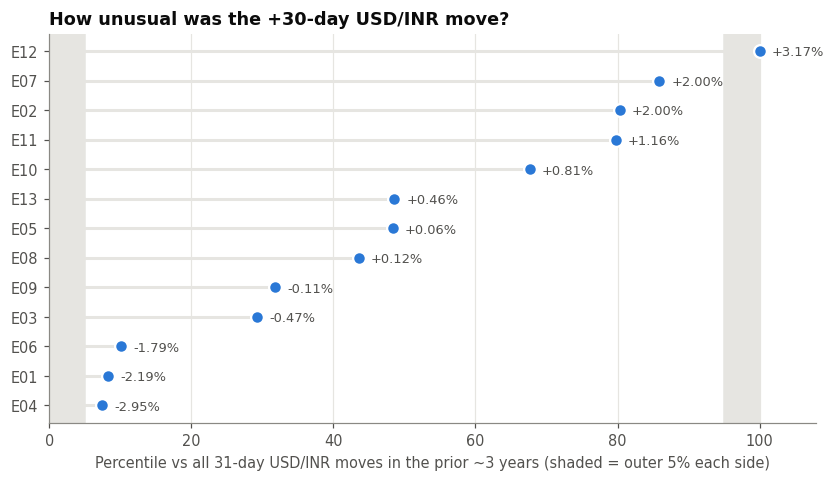

In [13]:
pc = ew[(ew.series_id == "USDINR") & (ew.window_id == "POST_30")][["event_id", "change", "percentile"]].dropna()
pc = pc.sort_values("percentile")
fig, ax = plt.subplots(figsize=(9, 4.6))
ax.axvspan(0, 5, color=GRID, zorder=0); ax.axvspan(95, 100, color=GRID, zorder=0)
ax.hlines(range(len(pc)), 0, pc.percentile, color=GRID, lw=2)
ax.scatter(pc.percentile, range(len(pc)), s=70, color=BLUE, edgecolor="white", linewidth=1.5, zorder=3)
for i, (_, r) in enumerate(pc.iterrows()):
    ax.annotate(f"{r.change:+.2f}%", (r.percentile, i), xytext=(8, -3), textcoords="offset points",
                fontsize=8.5, color=INK2)
ax.set_yticks(range(len(pc)), pc.event_id); ax.set_xlim(0, 108)
ax.set_xlabel("Percentile vs all 31-day USD/INR moves in the prior ~3 years (shaded = outer 5% each side)")
ax.set_title("How unusual was the +30-day USD/INR move?")
ax.grid(axis="y", visible=False)
save(fig, "09_move_percentiles"); plt.show()

## 9 · Why none of this proves causation

| What the data shows | Why it isn't a causal effect |
|---|---|
| USD/INR +6.0% in the 90 days after E05 (Jan 2020) | The window runs straight through the **COVID crash**, two emergency Fed cuts and two RBI cuts |
| USD/INR +6.4% in the 90 days after E07 (Feb 2022) | The broad US dollar rose **more** (+7.5%) during the 2022 Fed hiking cycle |
| Brent +6.5% on the E02 event day (Sep 2016) | That was **OPEC's output deal**, not India–Pakistan |
| E06 event day: −0.35% (RBI) vs +0.29% (Fed H.10) | The **sign flips** with the measurement clock |
| RBI sold US$17.4 bn in Feb–Apr 2022 | **Intervention** dampened the rupee's move, so the market move understates the pressure |

With 13 events, overlapping windows and no control group, the honest conclusion is **temporal association plus a
documented list of what else was moving**.

In [14]:
con.close()